In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
from tensorflow.keras.datasets import mnist
(X_train, y_train),( X_test, y_test) = mnist.load_data()

In [3]:
print(X_train.shape)  
print(y_train.shape)  
print(X_test.shape)   
print(y_test.shape)   

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


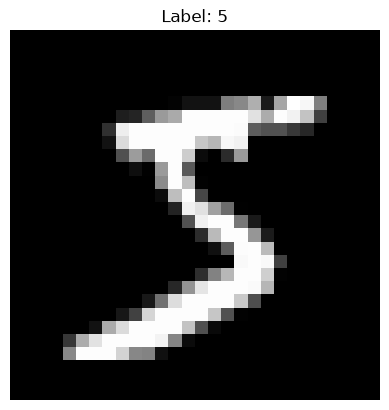

In [4]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
from tensorflow.keras.utils import to_categorical 
y_test_cat=to_categorical(y_test,10)
y_train_cat=to_categorical(y_train,10)

In [7]:
X_train_reshaped=X_train.reshape(-1,28,28,1)

In [8]:
X_train_reshaped.shape

(60000, 28, 28, 1)

In [9]:
X_train.shape

(60000, 28, 28)

In [10]:
X_test_reshaped=X_test.reshape(-1,28,28,1)

In [11]:
X_test_reshaped.shape

(10000, 28, 28, 1)

In [12]:
from sklearn.linear_model import Perceptron
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Dense   
from tensorflow.keras.layers import Conv2D     
from tensorflow.keras.layers import Flatten   
from tensorflow.keras.layers import MaxPooling2D    
from tensorflow.keras.layers import Dropout 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [13]:
model=Sequential([
    Flatten(input_shape=(28,28,1)),
    Dense(10,activation='softmax')
])

In [14]:
model.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [16]:
history=model.fit(X_train_reshaped,y_train_cat,validation_split=0.20,epochs=5,batch_size=32,verbose=1)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8046 - loss: 0.8412 - val_accuracy: 0.8780 - val_loss: 0.5033
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8754 - loss: 0.4868 - val_accuracy: 0.8931 - val_loss: 0.4156
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8872 - loss: 0.4265 - val_accuracy: 0.8992 - val_loss: 0.3798
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8933 - loss: 0.3964 - val_accuracy: 0.9033 - val_loss: 0.3599
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8970 - loss: 0.3774 - val_accuracy: 0.9074 - val_loss: 0.3466


In [17]:
acc_prep=model.evaluate(X_test_reshaped,y_test_cat,verbose=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9067 - loss: 0.3488


In [18]:
acc_prep

[0.3488041162490845, 0.9067000150680542]

In [19]:
ann=Sequential([
    Flatten(input_shape=(28,28,1)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [20]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [21]:
history_ann=ann.fit(X_train_reshaped,y_train_cat,validation_split=0.20,epochs=5,
                    batch_size=32,verbose=1)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9207 - loss: 0.2702 - val_accuracy: 0.9579 - val_loss: 0.1420
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9646 - loss: 0.1166 - val_accuracy: 0.9635 - val_loss: 0.1191
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9759 - loss: 0.0789 - val_accuracy: 0.9672 - val_loss: 0.1052
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9818 - loss: 0.0588 - val_accuracy: 0.9738 - val_loss: 0.0910
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9851 - loss: 0.0454 - val_accuracy: 0.9718 - val_loss: 0.0998


In [28]:
acc_ann=ann.evaluate(X_test_reshaped,y_test_cat)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9739 - loss: 0.0894


In [29]:
acc_ann

0.9739000201225281

In [24]:
X_train_reshaped.shape
X_test_reshaped.shape

(10000, 28, 28, 1)

In [25]:
cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),input_shape=(28,28,1),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [26]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
     

In [27]:
history_cnn = cnn.fit(X_train_reshaped, y_train_cat, epochs=5, batch_size=32, validation_split=0.20, verbose=1)
     

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 22ms/step - accuracy: 0.9271 - loss: 0.2352 - val_accuracy: 0.9819 - val_loss: 0.0614
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.9754 - loss: 0.0820 - val_accuracy: 0.9866 - val_loss: 0.0446
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9815 - loss: 0.0610 - val_accuracy: 0.9887 - val_loss: 0.0360
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.9859 - loss: 0.0473 - val_accuracy: 0.9895 - val_loss: 0.0379
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9873 - loss: 0.0407 - val_accuracy: 0.9912 - val_loss: 0.0331


In [30]:
acc_cnn = cnn.evaluate(X_test_reshaped , y_test_cat, verbose=0)[1]

In [31]:
acc_cnn

0.9919000267982483

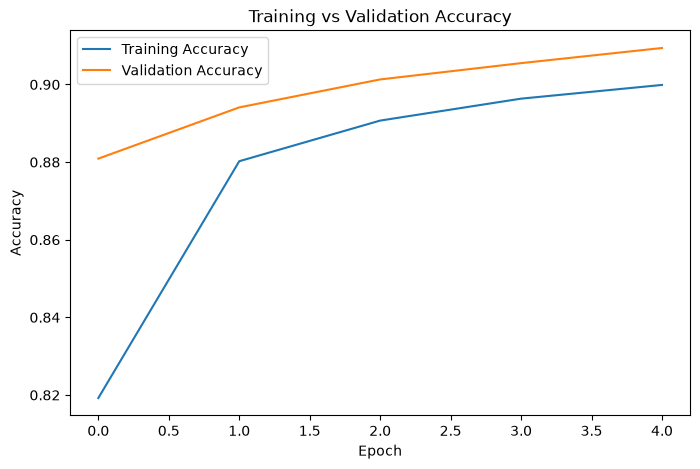

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

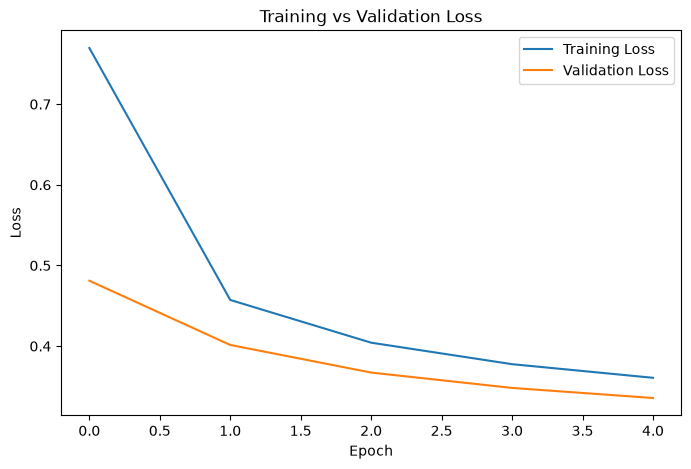

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

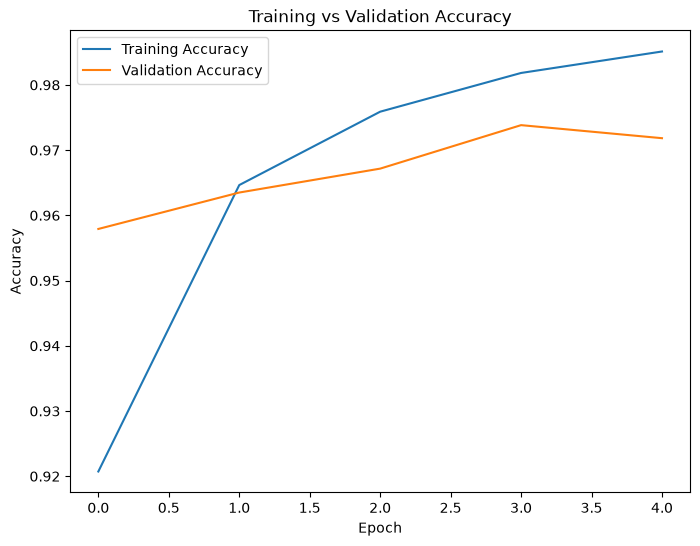

In [32]:
plt.figure(figsize=(8,6))
plt.plot(history_ann.history['accuracy'],label=['Training Accuracy'])
plt.plot(history_ann.history['val_accuracy'],label=['Validation Accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [33]:
cnn.save("mnist_cnn.keras")